In [1]:
from gradio_client import Client
from sentence_transformers import SentenceTransformer
from langchain.text_splitter import RecursiveCharacterTextSplitter
from sklearn.preprocessing import normalize
import faiss
import json
import re
from pprint import pprint
import torch
import faiss
import numpy as np
from bert_score import score

#  $\bold{Краткая \, выжимка \, того, \, что \, будет \, далее}$

Retrieval-Augmented Generation - способ увеличить точность предсказаний (зафайнтюнить модель) большой языковой seq2seq модели (называемой далее генератором) на специфических / не просмотренных при обучении данных.

Основу метода составляет использование векторной базы данных, наиболее релевантные записи из которой конкатенируются с основным запросом. Таким образом, 
нейросеть-генератор получает часть ответа в самом вопросе.

Почему используется именно векторная база данных? Потому что в ней можно легко ввести метрику схожести записей - евклидову, Cosine similarity или более сложную.

Как создавать векторную базу данных? Для этого нужна языковая модель (называемая далее энкодером), которая сопоставляет предложению на естественном языке некий вектор,
используя self-attention mechanism.

Можно ли использовать случайный энкодер? Да, но гарантировать, что на каждом естественном языке она будет хорошо сопоставлять записям вектора, нельзя.
На huggingface есть энкодеры, специально обученные под один из естественных языков.


# Шаг глубже

$\bold{Текст \, оригинальной \, статьи \, доступен \, по \, ссылке: \, https://arxiv.org/abs/2005.11401}$

В статье используют термины "параметрическая" и "непараметрическая" память. Под первой подразумевают предобученные веса генератора,
под второй - векторную базу данных.

Есть два подвида RAG:

1) RAG-Sequence Model: мы сначала ищем k наиболее релевантных записей в БД, конкатенируем их со всем запросом и один раз запускаем генератор;

2) RAG-Token Model: ищем топ-k записей вв БД для запроса, скармливаем модели-генератору, получаем от неё очередной токен, снова находим
топ-k документов для запроса + всех выданных моделью токенов, снова скармливаем генератору. И так, пока не дойдём до символа конца генерации EOS.

Ниже представлены различные скоры модели на датасете NQ с общими вопросами (например, "кто основал Гугл?") в зависимости от числа k

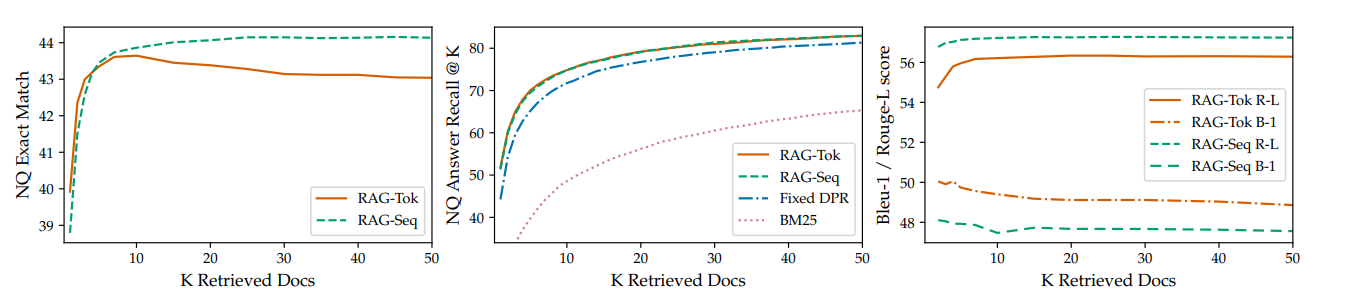

## Далее будем решать RAG-Sequence Model задачу

Пусть $z_i$ - полученные документы. $y$ - итоговый ответ генератора. Фактически, задача в состоит в следующем:

$ p_{RAG-Seq}(y|x) \approx \sum\limits_{z\in top-k(p(·|x))} p_{\eta} (z|x) \,\, p_{\theta}(y|x, z) = \sum\limits_{z\in top-k(p(·|x))}  p_{\eta} (z|x) \prod\limits_i^N p_{\theta}(y_i|x, z, y_{1:i−1}) $

Считается, что вероятность получить z-е документы с помощью энкодера с параметрами $\bold{\eta}$ при запросе x пропорционально скалярному произведению эмбеддингов запроса и документов:

$p_\eta (z|x) \propto exp(\bold{q}^T \, \bold{d}), \qquad \bold{d}(z) = BERT_d(z), \bold{q}(x) = BERT_q(x)$

В статье указано, что RAG-augmented *модель может достигать до 11,8% accuracy даже в тех вопросах, ответов на которые не было
в векторной базе данных*, при accuracy "сырой" модели 0%.

In [2]:
print(torch.cuda.is_available())

True


In [3]:
#загружаем документы в .txt формате

documents = []
text = ""
for i in range(1, 5):
    with open(f"{i}Ustav.txt", "r", encoding="utf-8") as doc:
        text = doc.read()
        documents.append({"tome" : i, "text" : text})

In [4]:
#очистка текста с помощью регулярных выражений
def clean_ustav_text(text):
    
    # 1. Убрать \x0c
    text = re.sub(r'\x0c', ' ', text)
    # 2. Убрать \x14 
    text = re.sub(r'\x14', '', text)
    # 3. Убрать спецсимволы
    text = re.sub(r'\x1f\n', '\n', text, flags=re.DOTALL)
    # 4. Убрать одинокие числа (например, номера страниц)
    text = re.sub(r'\n\d+\n', '\n', text)
    # 5. Удалить пробелы между словами, где это не нужно (опционально)
    text = re.sub(r'[ \t]{2,}', ' ', text)
    # 6. Заменить 2+ перевода строки на один
    text = re.sub(r'\n{2,}', '\n', text)
    # 7. Убрать лишние пробелы/табуляции в начале строк
    text = re.sub(r'^[ \t]+', '', text, flags=re.MULTILINE)
    # 8. Убрать лишние нижние подчеркивания
    text = re.sub(r'_{2,}', '_', text, flags=re.MULTILINE)

    cleaned_text = text.strip()

    return cleaned_text

In [5]:
for doc in documents:
    doc["text"] = clean_ustav_text(doc["text"])

In [6]:
#записываем на диск ля сохранности
with open("ustav_cleaned.jsonl", "w", encoding="utf-8") as f:
    for doc in documents:
        json.dump(doc, f, ensure_ascii=False)
        f.write("\n")

""" #при необходимости, читаем
documents = []
with open("ustav_cleaned.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        doc = json.loads(line)
        documents.append(doc) """

' #при необходимости, читаем\ndocuments = []\nwith open("ustav_cleaned.jsonl", "r", encoding="utf-8") as f:\n    for line in f:\n        doc = json.loads(line)\n        documents.append(doc) '

In [7]:
#разделяем документы на батчи, оставляем перекрытие по 50 символов для смысловой связи
splitter = RecursiveCharacterTextSplitter(chunk_size=450, chunk_overlap=100)

chunks = []
for doc in documents:
    for chunk in splitter.split_text(doc["text"]):
        chunks.append({"text": chunk, "source": doc["tome"]})

In [8]:
#делаем эмбеддинг документов с помощью модели, предобученной на русском корпусе
retriever = SentenceTransformer("ai-forever/sbert_large_nlu_ru", device="cuda")

texts = [chunk["text"] for chunk in chunks]
sources = [chunk['source'] for chunk in chunks]
d_embedding = retriever.encode(texts, batch_size=50, show_progress_bar=True)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

c:\Users\Артемий\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:144: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in D:\WorkD\pythonProjs\huggingFaceCache\hub\models--ai-forever--sbert_large_nlu_ru. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/195 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/2.05k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/1.27k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.71M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

Batches:   0%|          | 0/65 [00:00<?, ?it/s]

In [82]:
#формируе запросы
query_len = 27

queries = [""] * query_len
queries[0] = 'Какие обязанности дежурного по роте'
queries[1] = 'Обязанности военнослужащего перед построением и в строю'
queries[2] = 'Какой документ определяет права и обязанности военнослужащих в Вооружённых Силах РФ?'
queries[3] = 'Какие нормативные акты регулируют жизнь и быт в ВС РФ?'
queries[4] = 'Какой вид вооружённых сил защищает воздушное пространство?'
queries[5] = 'Когда в колонне воинское приветствие не делают?'

queries[6] = 'Кто несёт персональную ответственность за жизнь и здоровье подчинённых при выполнении боевых задач?'
queries[7] = 'Что является основным средством воспитания дисциплины среди личного состава?'
queries[8] = 'Какое нарушение считается наиболее тяжким проступком по Дисциплинарному уставу?'
queries[9] = 'Сколько видов поощрений предусмотрено для военнослужащих по Дисциплинарному уставу?'
queries[10] = 'Кто имеет право применять дисциплинарные взыскания к солдатам и сержантам?'
queries[11] = 'На каком расстоянии от командира строится подразделение перед началом занятий?'
queries[12] = 'Какие обязанности дежурного по роте'

queries[13] = 'Обязанности военнослужащего перед построением и в строю'
queries[14] = 'Как называется поворот на месте на 180 градусов?'
queries[15] = 'Какова глубина шага при движении строевым шагом?'
queries[16] = 'Какая задача считается главной для подразделения в бою?'
queries[17] = 'Что такое "огневой наряд"?'
queries[18] = 'Что понимается под "боевым охранением"?'

queries[19] = 'Что должен сделать командир отделения, если один из бойцов самовольно покинул позицию?'
queries[20] = 'Какой устав регулирует взаимоотношения между командирами и подчинёнными?'
queries[21] = 'Какие действия запрещены при проведении боевого тревожного порядка?'
queries[22] = 'Что обязан делать военнослужащий при получении неправильного (противозаконного) приказа?'
queries[23] = 'В чём заключается основная обязанность военнослужащего по контракту?'
queries[24] = 'Кто отвечает за сохранность и чистоту казармы?'

queries[25] = 'Как часто проводится осмотр обмундирования у военнослужащих?'
queries[26] = 'Что должен сделать военнослужащий при объявлении сигнала "Тревога"?'


In [83]:
q_embeddings = []
for i in range(query_len):
    q_embeddings.append(retriever.encode([queries[i]], show_progress_bar=True))

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [84]:
#сохраняем векторную ДБ, записываем cosine-similarity для неё
normalized_embeddings = normalize(np.array(d_embedding), axis=1)

dimension = len(normalized_embeddings[0])
index = faiss.IndexFlatIP(dimension)
#index = faiss.IndexFlatL2(dimension)
index.add(np.array(normalized_embeddings))

#можно сохранить на диск
faiss.write_index(index, "ustav_index.faiss")

""" #и прочитать
index = faiss.read_index("ustav_index.faiss") """

' #и прочитать\nindex = faiss.read_index("ustav_index.faiss") '

In [85]:
#ищем 5 наиболее релевантных документов
k = 5

In [86]:
#...и находим

indices = []
retrieved_docs = []
retrieved_tomes =  []

for i in range(query_len):

    _, indices = index.search(np.array(q_embeddings[i]), k)
    retrieved_docs.append([texts[idx] for idx in indices[0]])
    retrieved_tomes.append([sources[idx] for idx in indices[0]])

In [87]:
#конкатенируем найденное с запросом
full_inputs = [""] * query_len
context = [""] * query_len
for i in range(query_len):
    context[i] = "\n".join(retrieved_docs[i])
    full_inputs[i] = f"Question: {queries[i]}\nContext: {context[i]}"

In [88]:
#получаем доступ к генератору Qwen
client = Client("Qwen/Qwen2.5", verbose=True);

Loaded as API: https://qwen-qwen2-5.hf.space ✔


In [89]:
#делаем запросы без RAC
resultsBase = [""] * query_len

try:
    for i in range(query_len):
        resultsBase[i] = client.predict(
                    query=queries[i],
                    radio="72B",
                    api_name="/model_chat"
                );
    client.reset_session();

except Exception as e:
    print(f"Ошибка при обращении к API: {str(e)}")

In [90]:
#и с ним

results = [""] * query_len

try:
    for i in range(query_len):
        results[i] = client.predict(
                query=full_inputs[i],
                radio="72B",
                api_name="/model_chat"
            );
    client.reset_session();

except Exception as e:
    print(f"Ошибка при обращении к API: {str(e)}")

In [91]:
base_texts = []
rag_texts = []
for num in range(query_len):
    base_texts.append(resultsBase[num][1][0][1]['text'])
    rag_texts.append(results[num][1][0][1]['text'])

In [92]:
from sklearn.metrics.pairwise import cosine_similarity

q_embs = np.squeeze(q_embeddings, axis=1)
base_embs = retriever.encode(base_texts, show_progress_bar=True)
rag_embs = retriever.encode(rag_texts, show_progress_bar=True)

# Сходство вопроса с каждым ответом
sim_to_question_rag = cosine_similarity(q_embs, rag_embs).diagonal().mean()
sim_to_question_base = cosine_similarity(q_embs, base_embs).diagonal().mean()

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [93]:
sim_to_question_rag, sim_to_question_base

(0.61466, 0.61479765)